<a href="https://colab.research.google.com/github/reneeka-sharma/NeoSOFT_reeneka/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

%matplotlib inline


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [4]:
df = pd.read_csv("ppm_dummy_data.csv")

In [5]:
print("First 5 Rows:")
display(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Info:")
df.info()


First 5 Rows:


,Account_Key,Billing_Num,Book_key,Book_Cycle,Billing_Cycle,Balance,BAR,Total_Due,TDtoBRatio,Instalment,...,HomeNumber3_TelType,HomeNumber3_LatestDate,Employer1_OriginalEmployerName,Employer1_Occupation,Employer1_LatestDate,Employer1_EmployerTelephone,Employer2_OriginalEmployerName,Employer2_Occupation,Employer2_LatestDate,Employer2_EmployerTelephone
0,1104955506,2,664,Nov 2025,1,54297.61,0.9245,50199.54,0.9245,1274.78,...,Cell,2020-09-06,NaN,Consultant,2024-07-24,719015621.0,Shoprite,Manager,2019-09-14,NaN
1,1104951152,4,6634,Oct 2025,2,40717.83,0.3927,15990.69,0.3927,1382.79,...,Cell,2024-05-14,Eskom,Manager,2023-08-02,810378947.0,Eskom,NaN,2019-11-21,NaN
2,1106011444,1,6637,Nov 2025,4,14947.46,0.4821,7206.31,0.4821,494.67,...,Home,2021-12-18,Self Employed,NaN,2021-07-25,NaN,Self Employed,NaN,NaN,NaN
3,1106019167,4,6647,Nov 2025,3,44162.96,0.9494,41927.03,0.9494,1657.20,...,NaN,NaN,Sasol,Driver,NaN,NaN,Self Employed,Director,NaN,NaN
4,1106014362,1,664,Nov 2025,2,26620.48,0.4033,10735.72,0.4033,1491.31,...,Work,2023-08-16,NaN,NaN,2019-12-17,765304032.0,XYZ Ltd,Technician,2021-07-05,NaN



Shape:
(1000, 146)

Columns:
['Account_Key', 'Billing_Num', 'Book_key', 'Book_Cycle', 'Billing_Cycle', 'Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Opening_acc_status', 'Opening_acc_age', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'Deliquency', 'DC', 'TDtoBal', 'ARtoBal', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionScore', 'Digigroup', 'Contact_Score', 'Credit_Risk', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Total_Due', 'Previous_Payment', 'Previous_Payment_Amount', 'Previous_Payment_Perc', 'Previous_Cure', 'Curr


Current Payment Value Counts:
Current_Payment
0    741
1    259
Name: count, dtype: int64


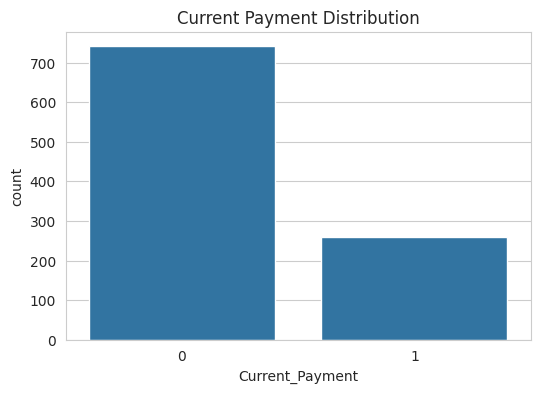

In [6]:
print("\nCurrent Payment Value Counts:")
print(df["Current_Payment"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Current_Payment", data=df)
plt.title("Current Payment Distribution")
plt.show()

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("\nTop Missing Values:")
if len(missing) > 0:
    print(missing.sort_values(ascending=False).head(20))
else:
    print("No missing values found.")



Top Missing Values:
Deceased1_DateOfDeath          1000
Deceased1_PlaceOfDeath         1000
Judgements1_PersonName         1000
Judgements1_Plaintiff          1000
Judgements1_Attorneys          1000
Address1_ComplexNumber          717
Employer2_EmployerTelephone     496
Employer1_EmployerTelephone     480
Person1_MarriageDate            479
CellNumber1_TelNumber           428
HomeNumber1_TelNumber           416
CellNumber3_Score               414
WorkNumber1_TelNumber           413
WorkNumber3_LatestDate          413
HomeNumber3_Score               412
CellNumber1_LatestDate          412
HomeNumber1_Score               411
HomeNumber2_TelType             406
WorkNumber3_Score               403
HomeNumber3_LatestDate          403
dtype: int64


In [8]:
# Numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print(f"\nTotal Numerical Features: {len(numerical_features)}")

Numerical Features:
['Account_Key', 'Billing_Num', 'Book_key', 'Billing_Cycle', 'Balance', 'BAR', 'Total_Due', 'TDtoBRatio', 'Instalment', 'Opening_Balance', 'Opening_Arrears', 'Opening_Total_Due', 'Opening_acc_status', 'Opening_acc_age', 'Current_Due', 'Xdays_Due', 'Due_30days', 'Due_60days', 'Due_90days', 'Due_120days', 'Due_150days', 'Due_180days', 'Due_210days', 'Current_per', 'Xdays_per', '30days_per', '60days_per', '90days_per', '120days_per', '150days_per', '180days_per', '210days_per', 'Deliquency', 'DC', 'TDtoBal', 'ARtoBal', 'Recency', 'Account_Age', 'Case_Age', 'Original_Band', 'Current_Band', 'Existing_Account', 'PropensistyToRol', 'BehaviourRiskScore', 'PaymentProjectionScore', 'Digigroup', 'Contact_Score', 'Credit_Risk', 'Missing', 'PContacts', 'PRPCs', 'PSMSs', 'PEmails', 'PLetters', 'PDOs', 'PPTPs', 'PAttempts', 'Previous_Account', 'Previous_Total_Due', 'Previous_Payment', 'Previous_Payment_Amount', 'Previous_Payment_Perc', 'Previous_Cure', 'Current_Payment', 'Current_P

Categorical Features:
['Book_Cycle', 'Person1_MaritalStatus', 'Person1_MarriageDate', 'Person1_Gender', 'Deceased1_IsDeceased', 'CreditScore1_CreditScoreCategory', 'Income1_Confidence', 'EagleEye1_HasDefault', 'EagleEye1_HasJudgment', 'EagleEye1_IsDirector', 'EagleEye1_UnderDebtReview', 'EagleEye1_OwnsProperty', 'EagleEye1_LastEmploymentUpdate', 'EagleEye1_HasPPAccounts', 'EagleEye1_HasPPAdverse', 'CellNumber1_TelType', 'CellNumber1_LatestDate', 'CellNumber2_TelType', 'CellNumber2_LatestDate', 'CellNumber3_TelType', 'CellNumber3_LatestDate', 'WorkNumber1_TelType', 'WorkNumber1_LatestDate', 'WorkNumber2_TelType', 'WorkNumber2_LatestDate', 'WorkNumber3_TelType', 'WorkNumber3_LatestDate', 'HomeNumber1_TelType', 'HomeNumber1_LatestDate', 'HomeNumber2_TelType', 'HomeNumber2_LatestDate', 'HomeNumber3_TelType', 'HomeNumber3_LatestDate', 'Employer1_OriginalEmployerName', 'Employer1_Occupation', 'Employer1_LatestDate', 'Employer2_OriginalEmployerName', 'Employer2_Occupation', 'Employer2_LatestD

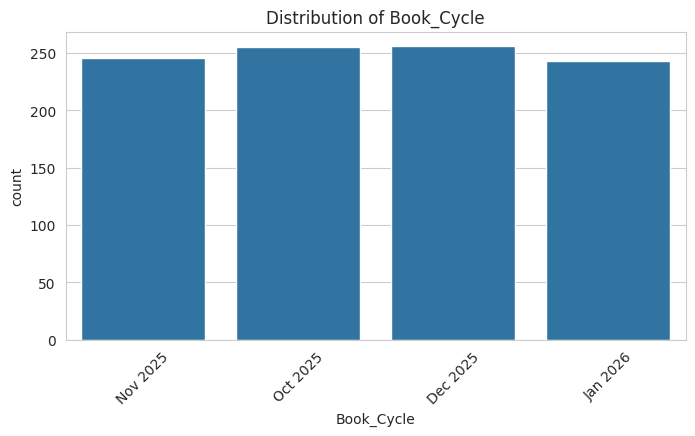

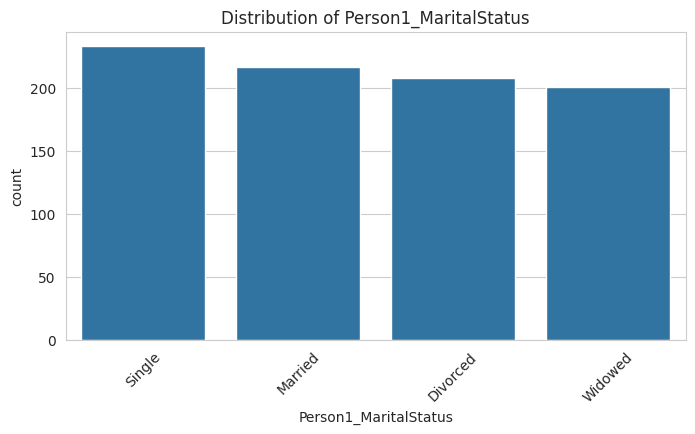

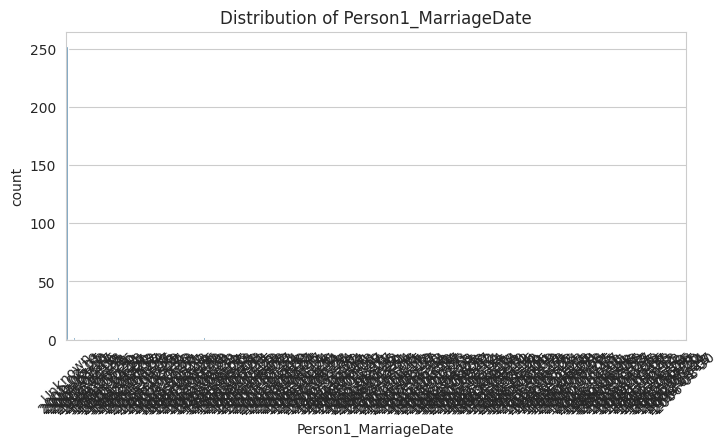

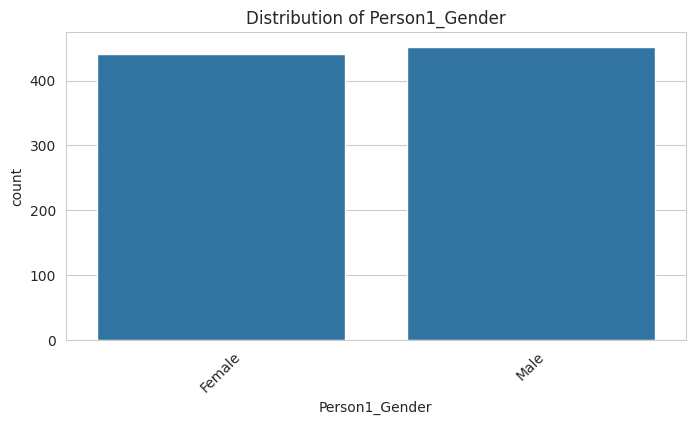

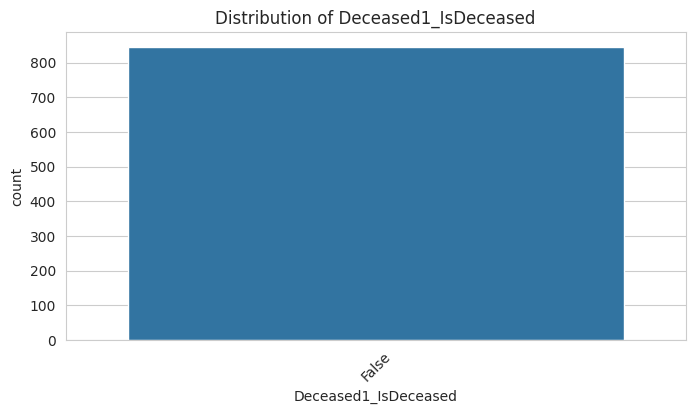

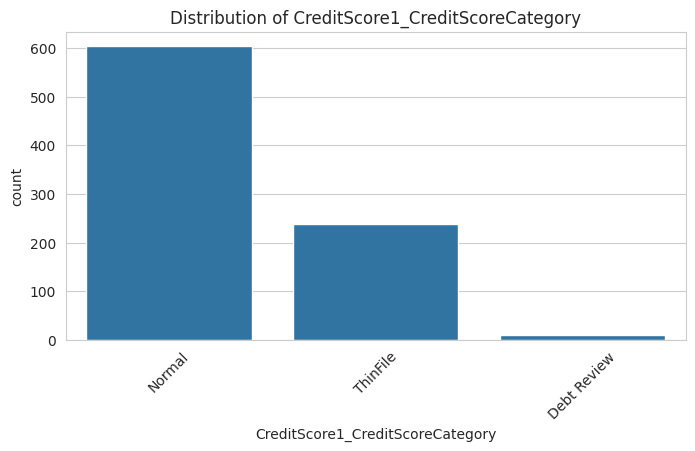

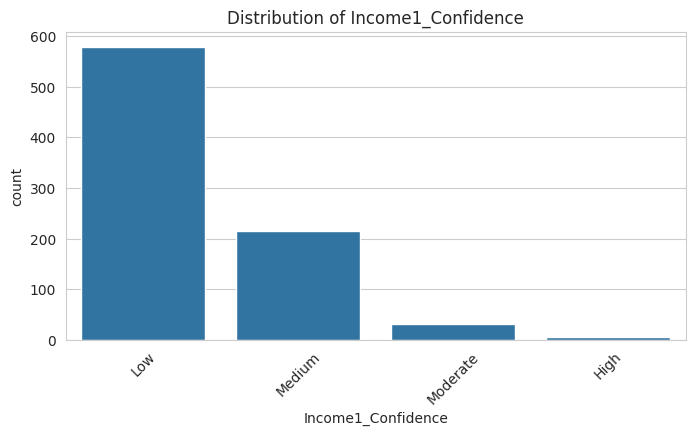

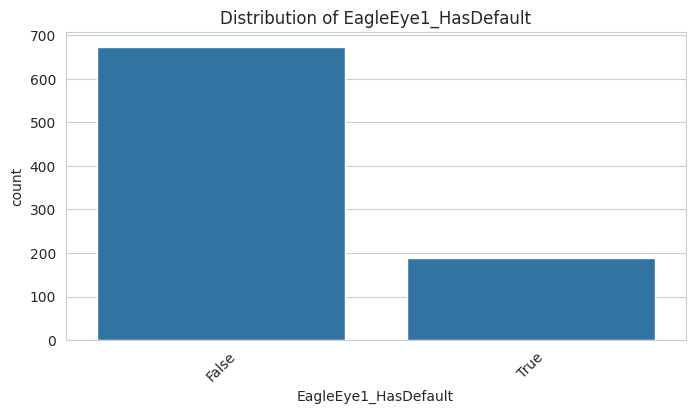

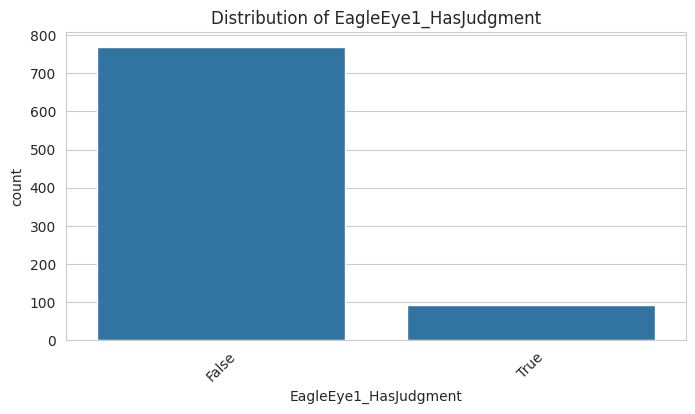

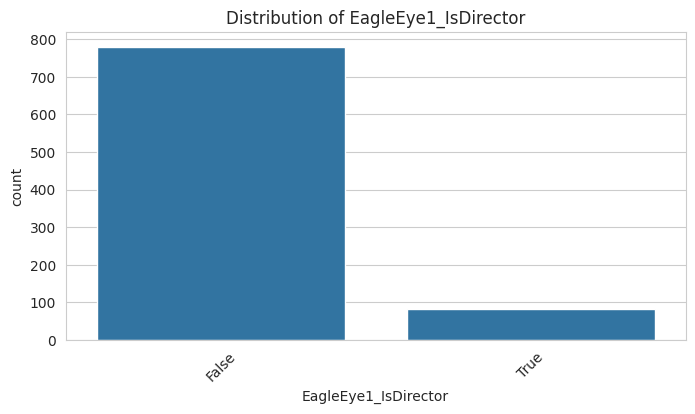

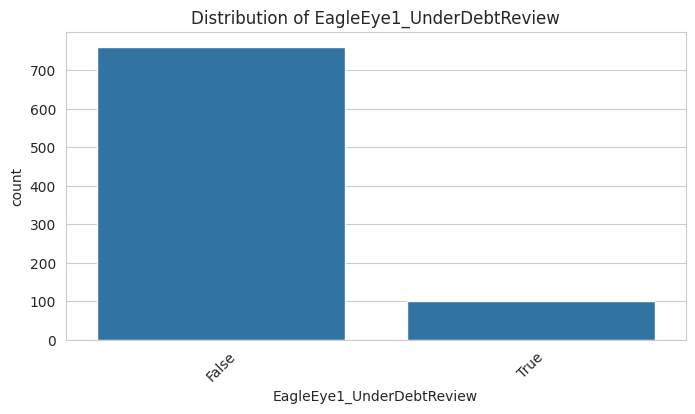

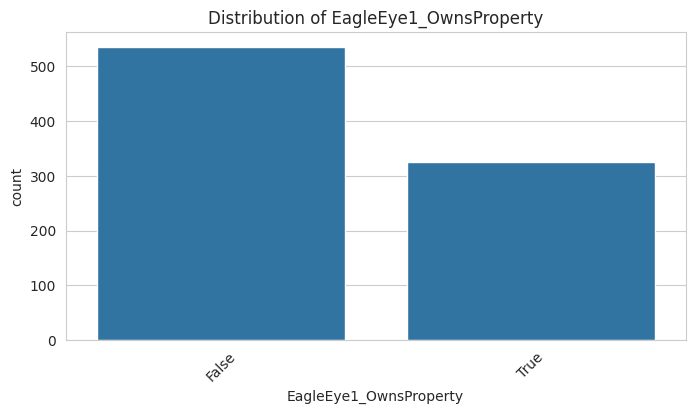

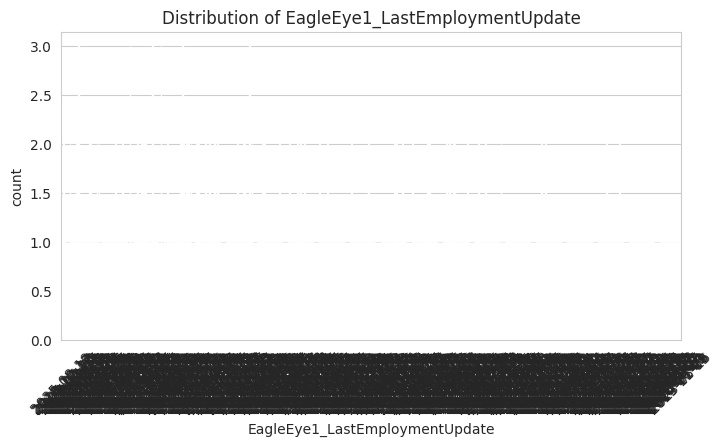

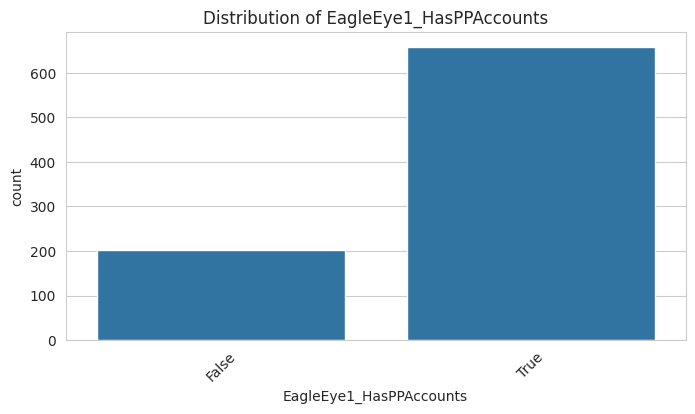

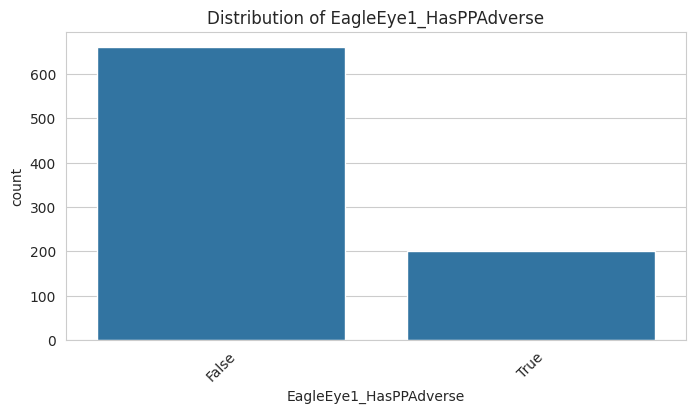

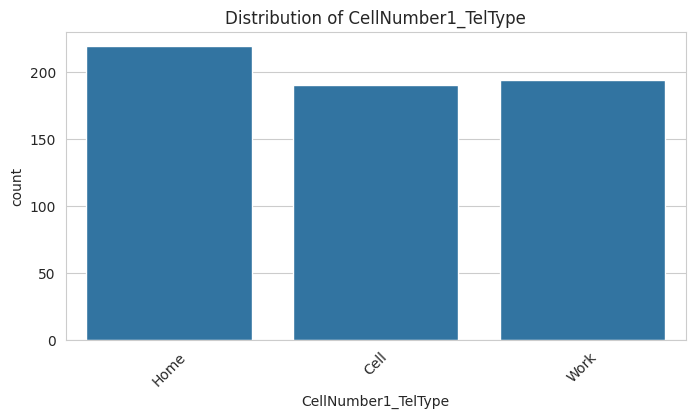

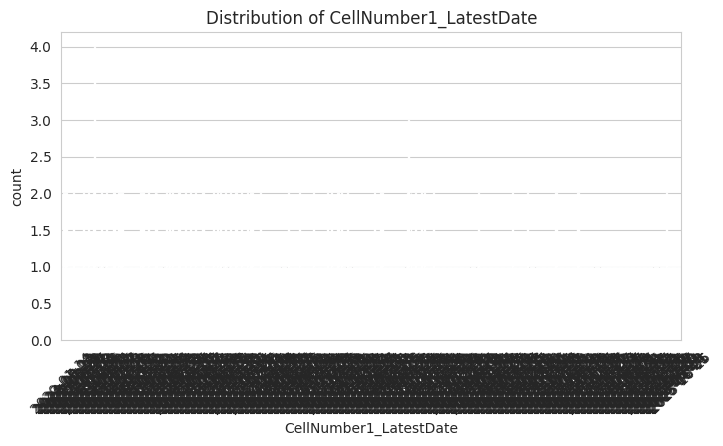

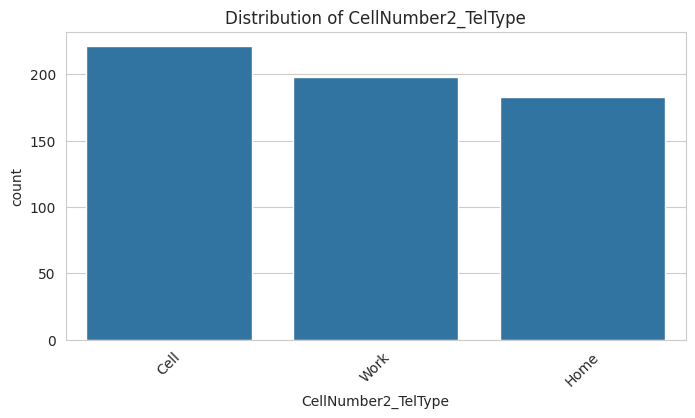

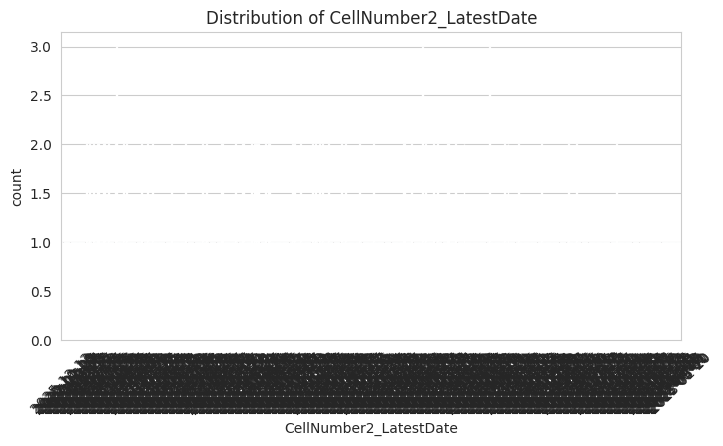

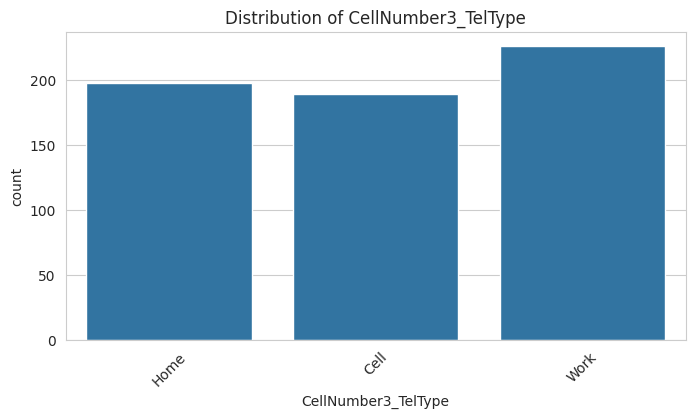

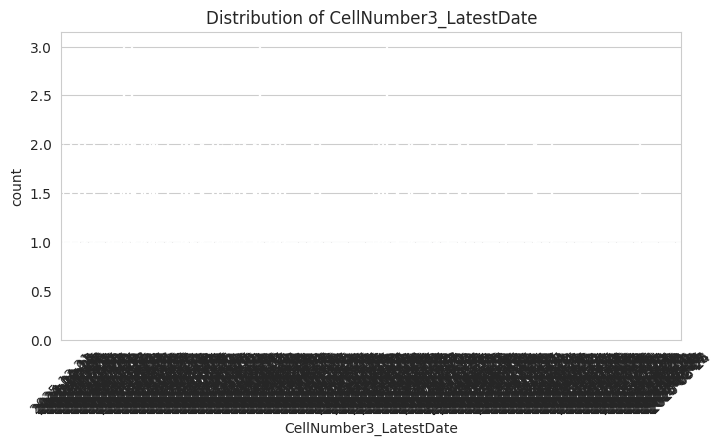

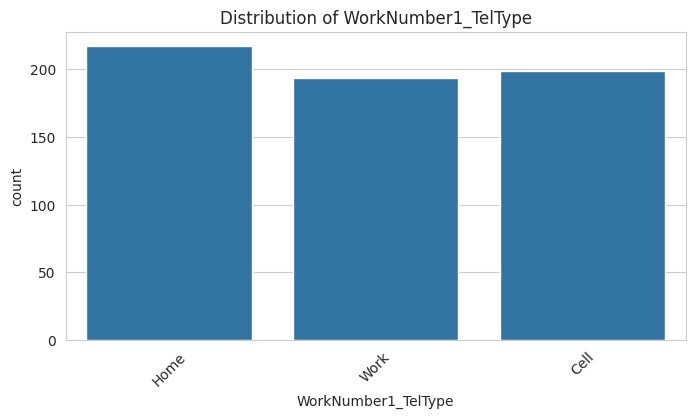

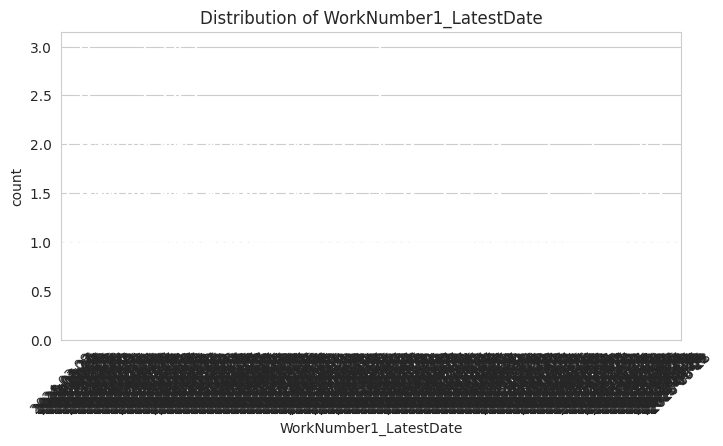

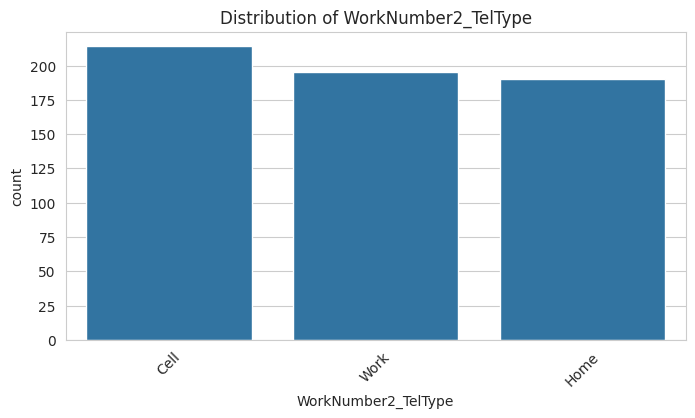

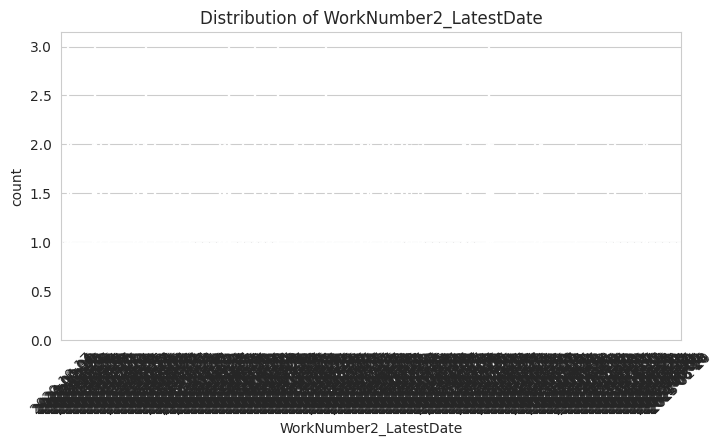

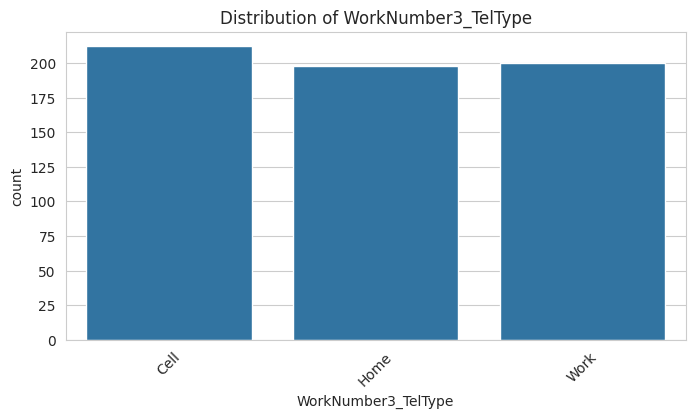

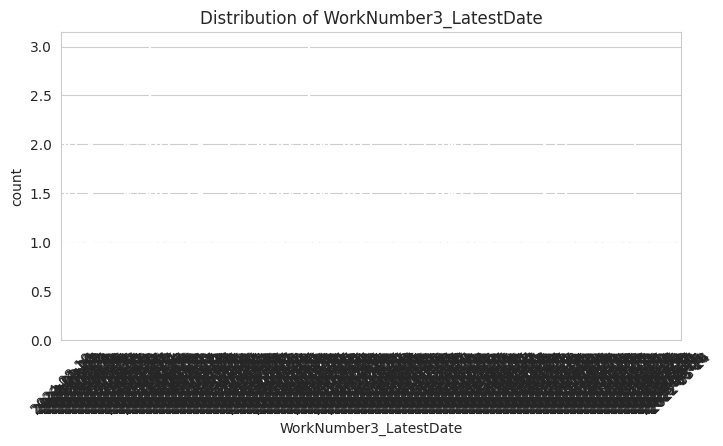

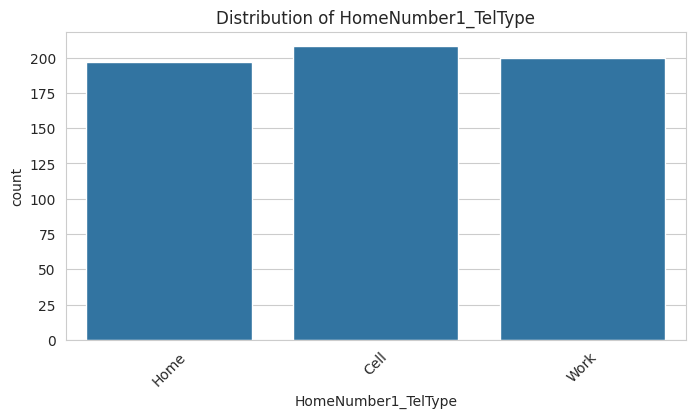

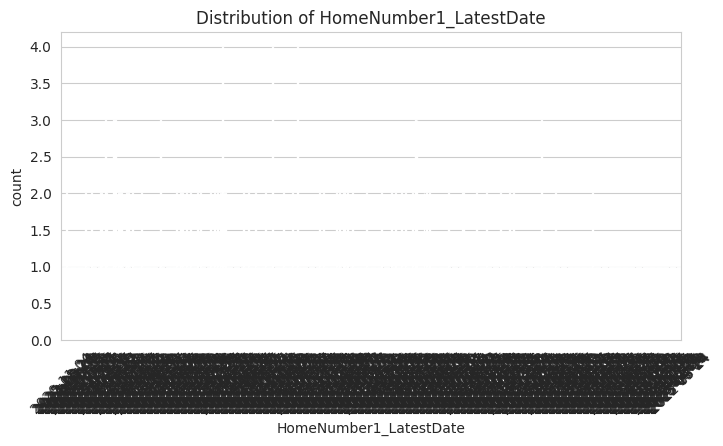

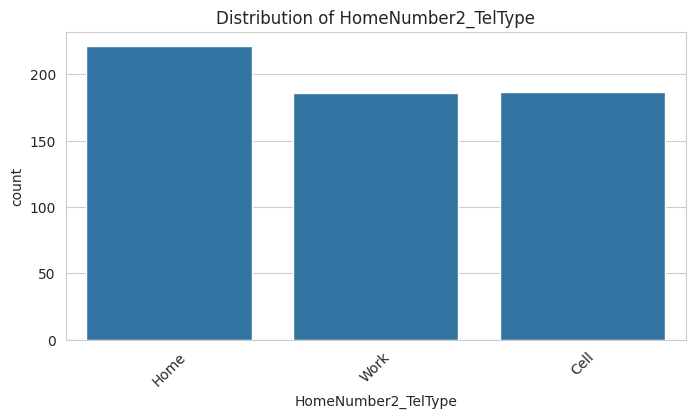

KeyboardInterrupt: 

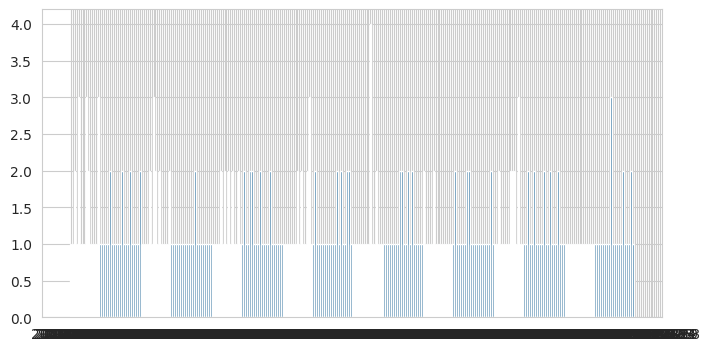

In [9]:
# Categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Features:")
print(categorical_features)
print(f"\nTotal Categorical Features: {len(categorical_features)}")
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [10]:
# Boolean columns
categorical_features = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(categorical_features)

['Book_Cycle', 'Person1_MaritalStatus', 'Person1_MarriageDate', 'Person1_Gender', 'Deceased1_IsDeceased', 'CreditScore1_CreditScoreCategory', 'Income1_Confidence', 'EagleEye1_HasDefault', 'EagleEye1_HasJudgment', 'EagleEye1_IsDirector', 'EagleEye1_UnderDebtReview', 'EagleEye1_OwnsProperty', 'EagleEye1_LastEmploymentUpdate', 'EagleEye1_HasPPAccounts', 'EagleEye1_HasPPAdverse', 'CellNumber1_TelType', 'CellNumber1_LatestDate', 'CellNumber2_TelType', 'CellNumber2_LatestDate', 'CellNumber3_TelType', 'CellNumber3_LatestDate', 'WorkNumber1_TelType', 'WorkNumber1_LatestDate', 'WorkNumber2_TelType', 'WorkNumber2_LatestDate', 'WorkNumber3_TelType', 'WorkNumber3_LatestDate', 'HomeNumber1_TelType', 'HomeNumber1_LatestDate', 'HomeNumber2_TelType', 'HomeNumber2_LatestDate', 'HomeNumber3_TelType', 'HomeNumber3_LatestDate', 'Employer1_OriginalEmployerName', 'Employer1_Occupation', 'Employer1_LatestDate', 'Employer2_OriginalEmployerName', 'Employer2_Occupation', 'Employer2_LatestDate']


Target Variable: Current_Payment

Target Distribution:
Current_Payment
0    741
1    259
Name: count, dtype: int64

Target Percentage Distribution:
Current_Payment
0    74.1
1    25.9
Name: proportion, dtype: float64


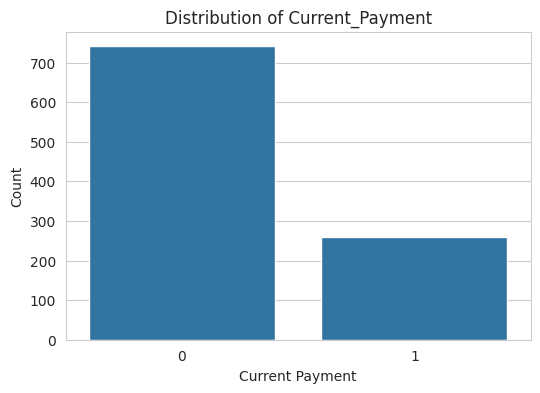

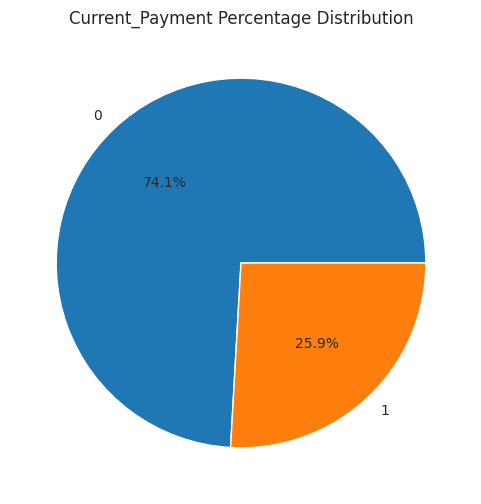

In [11]:
print("Target Variable: Current_Payment")

# Distribution
target_counts = df["Current_Payment"].value_counts()
print("\nTarget Distribution:")
print(target_counts)

# Percentage Distribution
target_percent = round(
    df["Current_Payment"].value_counts(normalize=True) * 100,
    2
)

print("\nTarget Percentage Distribution:")
print(target_percent)

# Visualization
plt.figure(figsize=(6,4))
sns.countplot(x="Current_Payment", data=df)
plt.title("Distribution of Current_Payment")
plt.xlabel("Current Payment")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
df["Current_Payment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Current_Payment Percentage Distribution")
plt.ylabel("")
plt.show()


Age Statistics:
count    921.000000
mean      46.550489
std       16.841005
min       18.000000
25%       32.000000
50%       47.000000
75%       61.000000
max       75.000000
Name: Age, dtype: float64


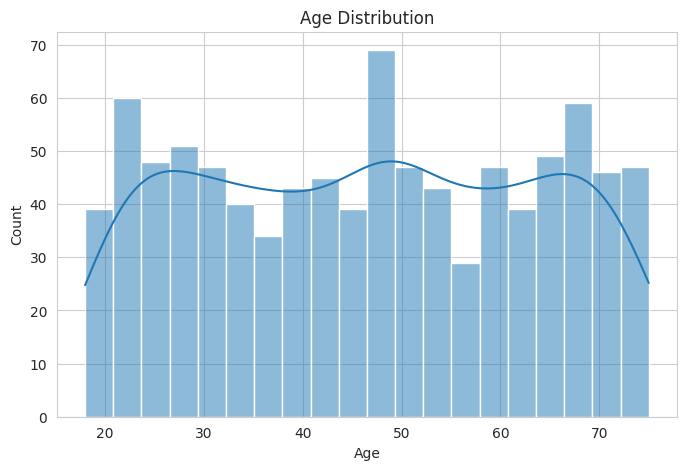

In [12]:
print("\nAge Statistics:")
print(df["Age"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()



Balance Statistics:
count     1000.000000
mean     40603.320140
std      22716.502572
min        539.050000
25%      20601.160000
50%      41429.610000
75%      59682.642500
max      79953.220000
Name: Balance, dtype: float64


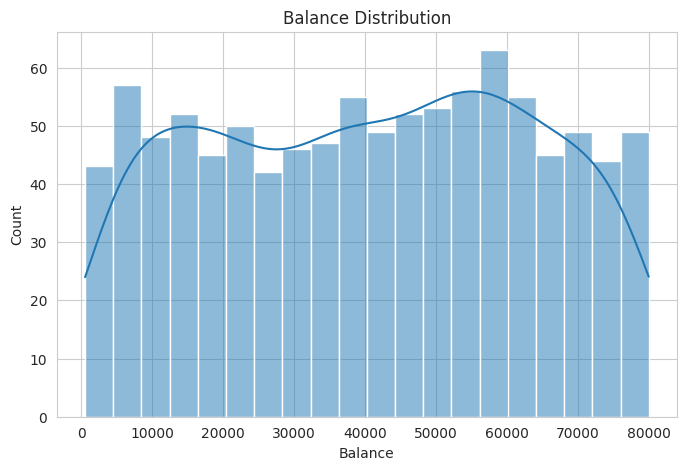

In [13]:
print("\nBalance Statistics:")
print(df["Balance"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["Balance"], bins=20, kde=True)
plt.title("Balance Distribution")
plt.show()


Delinquency Counts:
Deliquency
1    410
3    117
2     99
4     90
5     82
6     73
8     55
7     45
9     29
Name: count, dtype: int64


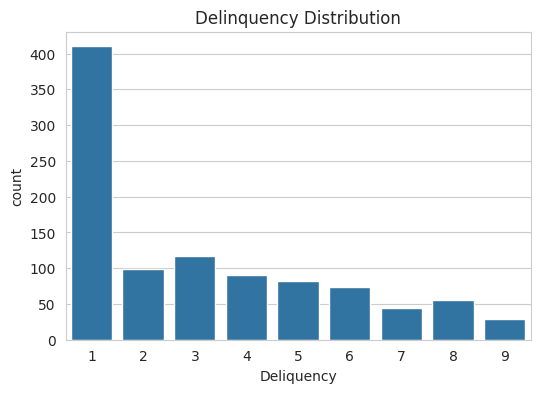

In [14]:
print("\nDelinquency Counts:")
print(df["Deliquency"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Deliquency", data=df)
plt.title("Delinquency Distribution")
plt.show()


In [15]:
print("\nPrevious Payment Counts:")
print(df["Previous_Payment"].value_counts())



Previous Payment Counts:
Previous_Payment
0    742
1    258
Name: count, dtype: int64


In [16]:
print("\nAverage Balance by Current Payment:")
print(df.groupby("Current_Payment")["Balance"].mean())

print("\nAverage Delinquency by Current Payment:")
print(df.groupby("Current_Payment")["Deliquency"].mean())

print("\nAverage Age by Current Payment:")
print(df.groupby("Current_Payment")["Age"].mean())



Average Balance by Current Payment:
Current_Payment
0    40587.155169
1    40649.568185
Name: Balance, dtype: float64

Average Delinquency by Current Payment:
Current_Payment
0    2.931174
1    3.903475
Name: Deliquency, dtype: float64

Average Age by Current Payment:
Current_Payment
0    46.459302
1    46.819742
Name: Age, dtype: float64



Recency Statistics:
count    1000.000000
mean     2487.139000
std      4304.454271
min         0.000000
25%        13.000000
50%        27.000000
75%        76.000000
max      9999.000000
Name: Recency, dtype: float64


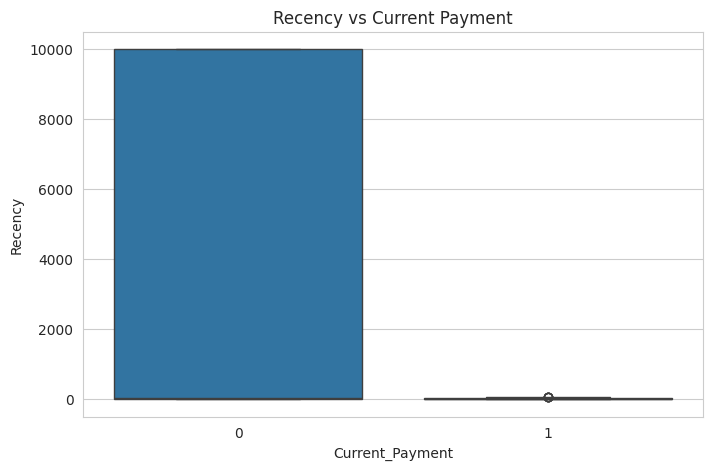

In [17]:
print("\nRecency Statistics:")
print(df["Recency"].describe())

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Current_Payment",
    y="Recency",
    data=df
)
plt.title("Recency vs Current Payment")
plt.show()

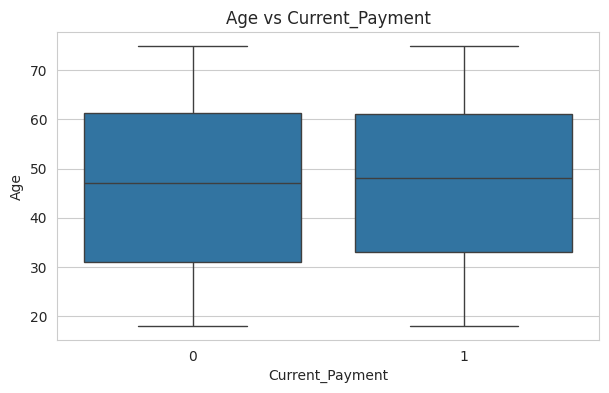

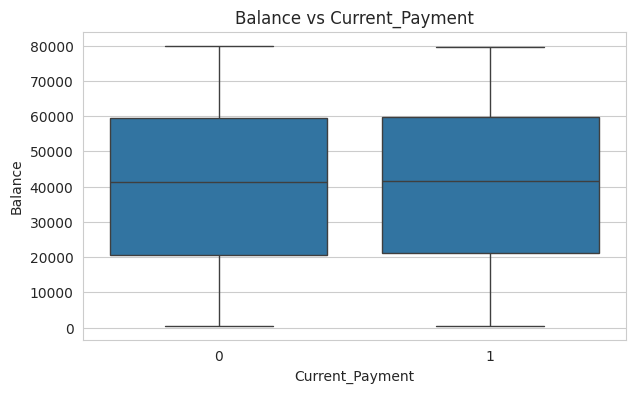

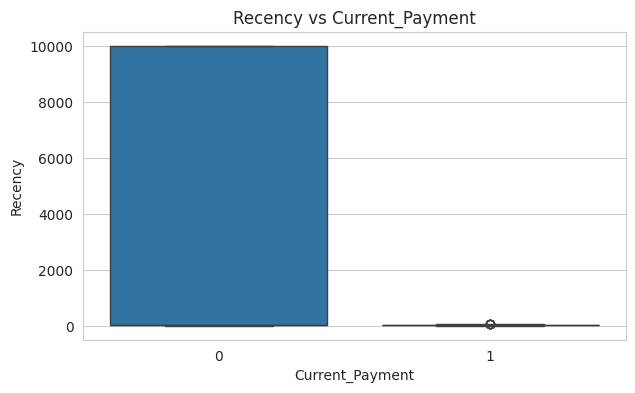

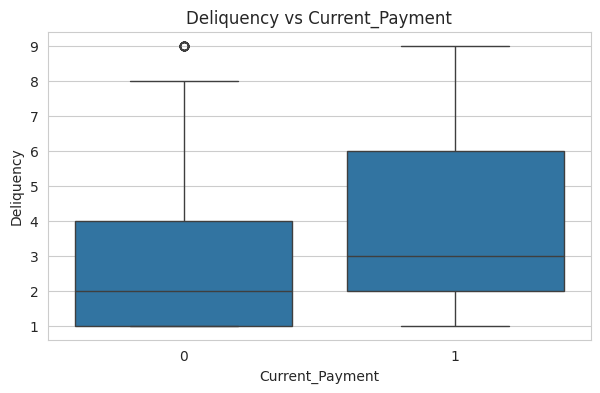

In [18]:
numerical_cols = ["Age", "Balance", "Recency", "Deliquency"]

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        x="Current_Payment",
        y=col,
        data=df
    )
    plt.title(f"{col} vs Current_Payment")
    plt.show()


Correlation Matrix:


,Balance,Deliquency,Recency,Age,Current_Payment
Balance,1.000000,-0.040158,0.068347,0.021477,0.001204
Deliquency,-0.040158,1.000000,-0.514056,-0.023115,0.175072
Recency,0.068347,-0.514056,1.000000,0.005215,-0.338641
Age,0.021477,-0.023115,0.005215,1.000000,0.009309
Current_Payment,0.001204,0.175072,-0.338641,0.009309,1.000000


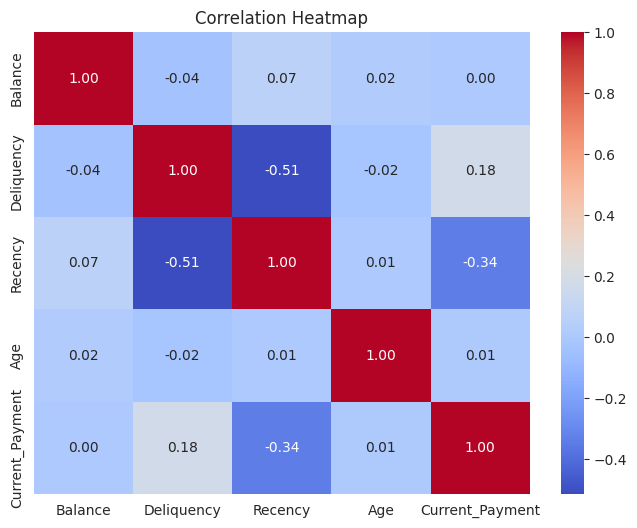

In [19]:
corr_cols = [
    "Balance",
    "Deliquency",
    "Recency",
    "Age",
    "Current_Payment"
]

corr = df[corr_cols].corr()

print("\nCorrelation Matrix:")
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()